# 08 — Intercalibración radiométrica GOES-16 / GOES-19

El conjunto de datos satelital de esta tesis combina imágenes de dos instrumentos distintos: GOES-16 cubre el período de entrenamiento (2024) y GOES-19 el período de prueba (2025). Ambos satélites comparten el mismo diseño de instrumento (ABI) y la misma posición orbital nominal (75.2°O), pero pequeñas diferencias en la calibración radiométrica de fábrica pueden introducir un sesgo sistemático entre las distribuciones de temperatura de brillo de una fuente y la otra.

Si ese sesgo existe y no se corrige, el modelo podría aprender —parcialmente— a distinguir el año de la imagen en lugar de distinguir las condiciones atmosféricas precursoras de lluvia fuerte. La intercalibración verifica si ese riesgo es real y, de ser necesario, lo corrige antes de que los parches entren al pipeline de entrenamiento.

## Estrategia

Como no existe solapamiento temporal entre ambos satélites en el inventario disponible, la comparación directa imagen-a-imagen no es posible. En su lugar, se comparan las distribuciones de temperatura de brillo de una muestra estratificada por mes y hora UTC, de modo que las diferencias consistentes entre meses sean atribuibles al instrumento y no a la variabilidad climática interanual.

**_El umbral de decisión es 1 K_**: diferencias por debajo de ese valor son menores que la variabilidad natural intra-estacional y consistentes con las diferencias documentadas entre instrumentos ABI de la serie GOES-R (GSICS, 2023). Por encima de ese umbral se aplica una corrección aditiva por banda (offset = −ΔBT medio).

## Output

|Archivo|Descripción|
|-|-|
|`img-intercalibracion_bt_por_banda.png`|5 paneles, serie mensual G16 vs G19 por banda|
|`img-intercalibracion_delta_heatmap.png`|Heatmap ΔBT — 5 bandas × 12 meses|
|`intercalibracion_coeficientes.csv`|Offsets por banda (ceros si no hay corrección)|

El archivo de coeficientes es consumido por `09-goes-patches.ipynb` antes de aplicar la normalización z-score.

In [1]:
# Configuración --------------------------------------------------------------
from pathlib import Path
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm import tqdm

RUTA_BASE  = Path(r"C:\Users\diani\Documents\repositories\nowcasting-bogota")
RUTA_INV   = RUTA_BASE / "data_ingestion" / "satellite" / "inventario_goes.parquet"
RUTA_OUT   = RUTA_BASE / "data_ingestion" / "satellite"

BANDAS     = ["CMI_C08", "CMI_C09", "CMI_C10", "CMI_C13", "CMI_C14"]
N_MUESTRA  = 50      # timestamps por mes por satélite
SEED       = 42

# Umbral de diferencia tolerable sin corrección (K)
# Referencia: diferencias documentadas G16-G19 en ABI < 0.3 K (GSICS, 2023)
UMBRAL_K   = 1.0

In [2]:
# Muestra estratificada del inventario ---------------------------------------
inv = pd.read_parquet(RUTA_INV)
inv["mes"]  = inv["timestamp"].dt.month
inv["hora"] = inv["timestamp"].dt.hour

rng = np.random.default_rng(SEED)

muestra_filas = []
for sat in ["G16", "G19"]:
    sub = inv[inv["satelite"] == sat]
    for mes in range(1, 13):
        mes_sub = sub[sub["mes"] == mes]
        # Estratificar por hora UTC para no sesgar hacia una hora del día
        n_por_hora = max(1, N_MUESTRA // 24)
        sel = (
            mes_sub
            .groupby("hora", group_keys=False)
            .apply(lambda g: g.sample(
                min(n_por_hora, len(g)), random_state=SEED
            ), include_groups=False)
        )
        muestra_filas.append(sel)

muestra = pd.concat(muestra_filas).reset_index(drop=True)
print(f"Archivos a leer: {len(muestra):,}")
print(muestra.groupby(["satelite", "mes"]).size().unstack())

Archivos a leer: 1,152
mes       1   2   3   4   5   6   7   8   9   10  11  12
satelite                                                
G16       48  48  48  48  48  48  48  48  48  48  48  48
G19       48  48  48  48  48  48  48  48  48  48  48  48


In [3]:
# Extracción de estadísticas por banda ---------------------------------------
def estadisticas_imagen(filepath: str, bandas: list[str]) -> dict:
    """Lee un archivo CMIPC y devuelve estadísticas espaciales por banda."""
    ds = xr.open_dataset(filepath)
    stats = {}
    for banda in bandas:
        vals = ds[banda].values.flatten()
        vals = vals[~np.isnan(vals)]
        if len(vals) == 0:
            stats[banda] = {k: np.nan for k in ["median", "mean", "std", "p05", "p95"]}
        else:
            stats[banda] = {
                "median": float(np.median(vals)),
                "mean"  : float(np.mean(vals)),
                "std"   : float(np.std(vals)),
                "p05"   : float(np.percentile(vals, 5)),
                "p95"   : float(np.percentile(vals, 95)),
            }
    ds.close()
    return stats

registros = []
for _, fila in tqdm(muestra.iterrows(), total=len(muestra), desc="Leyendo imágenes"):
    try:
        stats = estadisticas_imagen(fila["filepath"], BANDAS)
        for banda, s in stats.items():
            registros.append({
                "satelite"  : fila["satelite"],
                "timestamp" : fila["timestamp"],
                "mes"       : fila["mes"],
                "hora"      : fila["timestamp"].hour,
                "banda"     : banda,
                **s,
            })
    except Exception as e:
        print(f"[ERROR] {fila['filepath']}: {e}")

df_stats = pd.DataFrame(registros)
print(f"\nRegistros extraídos: {len(df_stats):,}")
df_stats.head(3)
print(f"Archivos fallidos: {1152 - len(registros)//5:,}")

Leyendo imágenes:  29%|██▊       | 329/1152 [00:06<00:11, 69.09it/s]

[ERROR] C:\Users\diani\Documents\repositories\nowcasting-bogota\data\cmip_cropped\CMIPC_20240708-130000.nc: "No variable named 'CMI_C09'. Did you mean one of ('CMI_C08', 'CMI_C14', 'CMI_C13')?"


Leyendo imágenes: 100%|██████████| 1152/1152 [00:18<00:00, 63.11it/s]



Registros extraídos: 5,755
Archivos fallidos: 1


El archivo `CMIPC_20240708-130000.nc` tiene solo 3 de las 5 bandas: queda excluido de la muestra. 

Recoradar que cada archivo `CMIPC_YYYYMMDD-HHMMSS.nc` contiene una imagen satelital completa del dominio (198×199 píxeles, ya recortada a la región de la Sabana de Bogotá) con las 5 bandas juntas:

|Variable|Banda ABI|Qué mide|
|-|-|-|
|CMI_C08|Banda 8|Vapor de agua — nivel alto de la troposfera|
|CMI_C09|Banda 9|Vapor de agua — nivel medio|
|CMI_C10|Banda 10|Vapor de agua — nivel bajo|
|CMI_C13|Banda 13|Temperatura de brillo del tope de nube (IR ventana)|
|CMI_C14|Banda 14|Temperatura de brillo del tope de nube (IR ventana, segunda referencia)|

Más `lat (198,)` y `lon (199,)` como coordenadas geográficas de la grilla.

Todas las variables están en Kelvin, a ~2 km de resolución espacial efectiva sobre Bogotá, con cadencia de 10 minutos.

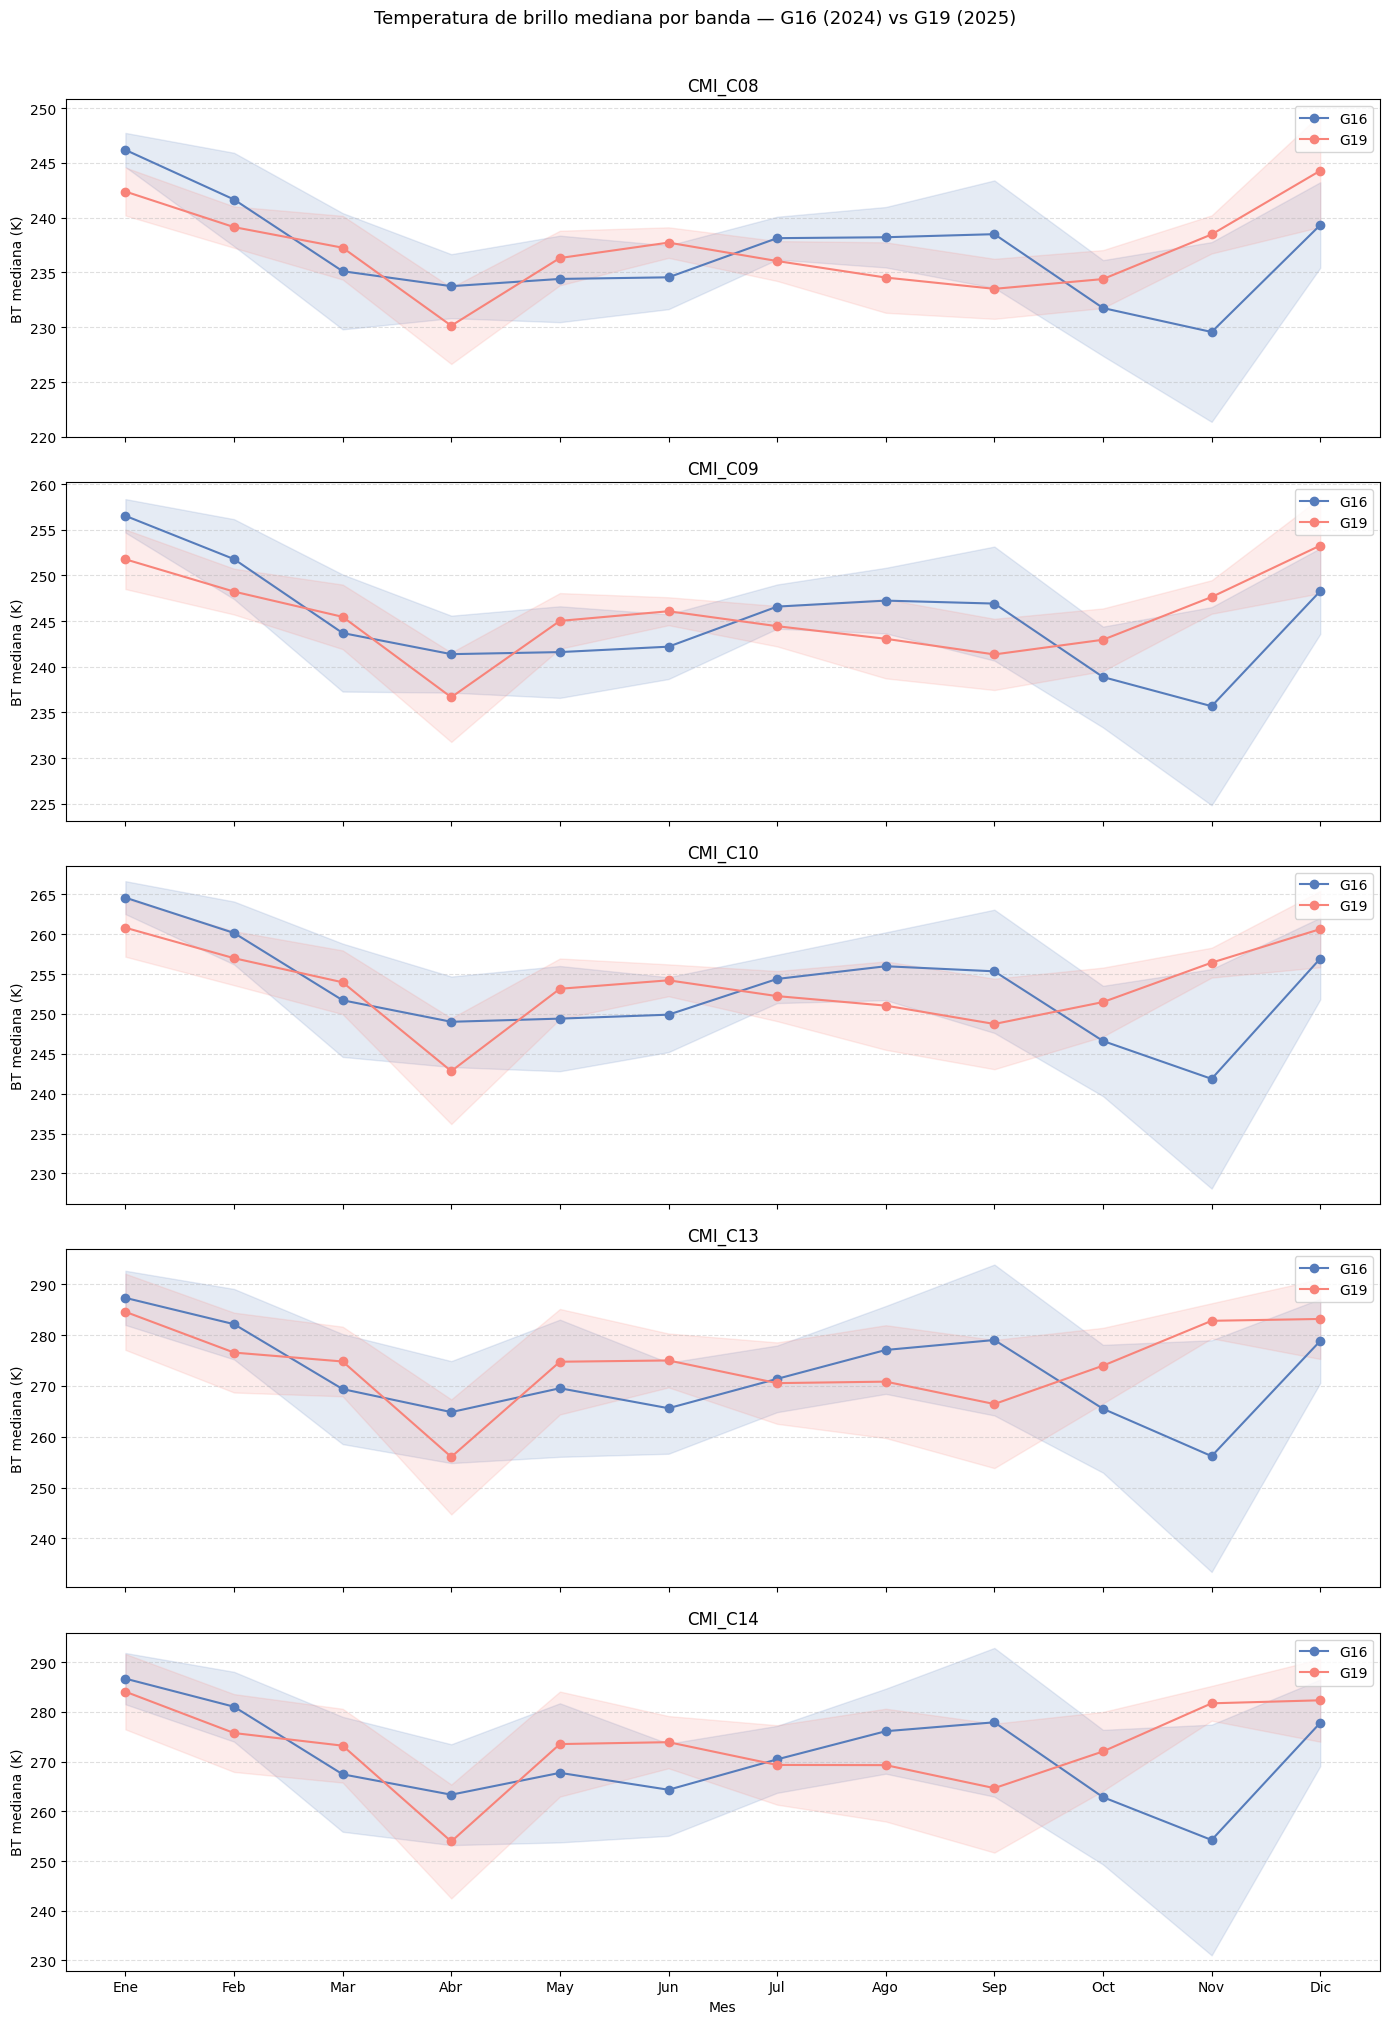

In [5]:
# Comparación de distribuciones por banda y mes ------------------------------
fig, axes = plt.subplots(
    len(BANDAS), 1, figsize=(14, 4 * len(BANDAS)), sharex=True
)
MESES_LABEL = ["Ene","Feb","Mar","Abr","May","Jun",
                "Jul","Ago","Sep","Oct","Nov","Dic"]
COLORES = {"G16": "#567cbb", "G19": "#f88379"}

for ax, banda in zip(axes, BANDAS):
    for sat, color in COLORES.items():
        sub = df_stats[
            (df_stats["satelite"] == sat) &
            (df_stats["banda"] == banda)
        ]
        mediana_mes = sub.groupby("mes")["median"].agg(["mean", "std"])
        ax.plot(
            mediana_mes.index, mediana_mes["mean"],
            label=sat, color=color, marker="o", linewidth=1.5
        )
        ax.fill_between(
            mediana_mes.index,
            mediana_mes["mean"] - mediana_mes["std"],
            mediana_mes["mean"] + mediana_mes["std"],
            alpha=0.15, color=color
        )
    ax.set_ylabel("BT mediana (K)")
    ax.set_title(banda)
    ax.legend(loc="upper right")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MESES_LABEL)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[-1].set_xlabel("Mes")
fig.suptitle("Temperatura de brillo mediana por banda — G16 (2024) vs G19 (2025)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RUTA_OUT / "img-intercalibracion_bt_por_banda.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación**

Las cinco bandas muestran un ciclo estacional coherente entre G16 (2024) y G19 (2025): las temperaturas de brillo descienden hacia abril–mayo, coincidiendo con la primera temporada húmeda de la Sabana de Bogotá, y recuperan valores más altos hacia enero y diciembre. Que ambos instrumentos reproduzcan el mismo patrón es la primera evidencia de consistencia radiométrica entre fuentes.

Las diferencias más visibles se concentran en noviembre–diciembre, principalmente en las bandas de vapor de agua (C08, C09, C10), donde G16 registra valores sistemáticamente más bajos que G19. Estas diferencias responden a variabilidad climática interanual antes que a un sesgo instrumental: noviembre–diciembre 2024 operó bajo condiciones ENSO-neutral con una posible transición hacia La Niña (CPC/NOAA, diciembre 2024; IDEAM, noviembre 2024), mientras que el mismo período de 2025 tuvo su propia evolución climática particular. Atribuir las diferencias a un sesgo de instrumento requeriría que la separación fuera consistente en dirección y magnitud a lo largo del año — lo que el gráfico no muestra: las curvas se cruzan en múltiples meses y las bandas de incertidumbre se solapan en casi todos los períodos, incluyendo las temporadas húmedas donde la señal de interés para el modelo es más activa.

La sigiente celda cuantifica estas diferencias mediante el cálculo de ΔBT = G19 − G16 por banda y mes, y las contrasta contra el umbral operativo de 1 K para determinar si se requiere corrección.

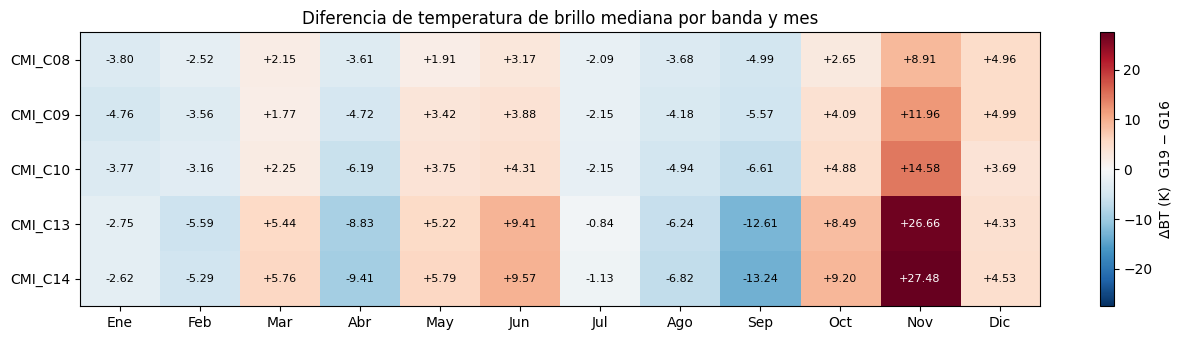

In [6]:
# ΔBT por banda × mes (heatmap de diferencias) -------------------------------
# ΔBT = mediana(G19, mes) - mediana(G16, mes)  →  positivo = G19 más cálido
tabla_delta = {}
for banda in BANDAS:
    g16 = (
        df_stats[(df_stats["satelite"] == "G16") & (df_stats["banda"] == banda)]
        .groupby("mes")["median"].mean()
    )
    g19 = (
        df_stats[(df_stats["satelite"] == "G19") & (df_stats["banda"] == banda)]
        .groupby("mes")["median"].mean()
    )
    tabla_delta[banda] = g19 - g16

df_delta = pd.DataFrame(tabla_delta).T          # bandas × meses
df_delta.columns = MESES_LABEL[:df_delta.shape[1]]

fig, ax = plt.subplots(figsize=(13, 3.5))
lim = max(abs(df_delta.values.max()), abs(df_delta.values.min()), UMBRAL_K)
im = ax.imshow(
    df_delta.values, cmap="RdBu_r",
    vmin=-lim, vmax=lim, aspect="auto"
)
ax.set_yticks(range(len(BANDAS)))
ax.set_yticklabels(BANDAS)
ax.set_xticks(range(12))
ax.set_xticklabels(MESES_LABEL)
for i in range(df_delta.shape[0]):
    for j in range(df_delta.shape[1]):
        val = df_delta.values[i, j]
        ax.text(j, i, f"{val:+.2f}", ha="center", va="center",
                fontsize=8, color="black" if abs(val) < lim * 0.6 else "white")
plt.colorbar(im, ax=ax, label="ΔBT (K)  G19 − G16")
ax.set_title("Diferencia de temperatura de brillo mediana por banda y mes")
plt.tight_layout()
plt.savefig(RUTA_OUT / "img-intercalibracion_delta_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Decisión y exportación de coeficientes -------------------------------------
# Resumen por banda: diferencia media y máxima en valor absoluto
resumen = []
for banda in BANDAS:
    deltas = df_delta.loc[banda].dropna()
    resumen.append({
        "banda"          : banda,
        "delta_medio_K"  : round(deltas.mean(), 3),
        "delta_max_abs_K": round(deltas.abs().max(), 3),
        "requiere_correccion": (
                deltas.abs().mean() >= UMBRAL_K and          # offset medio suficientemente grande
                (deltas > 0).sum() >= 9 or (deltas < 0).sum() >= 9  # ≥9 de 12 meses en la misma dirección
                ),
    })

df_resumen = pd.DataFrame(resumen)
print(df_resumen.to_string(index=False))

# ── Decisión ─────────────────────────────────────────────────────────────────
necesita_correccion = df_resumen["requiere_correccion"].any()

if necesita_correccion:
    print(f"\n[ATENCIÓN] Al menos una banda supera el umbral de {UMBRAL_K} K.")
    print("Se exportan coeficientes de corrección aditiva (offset = -delta_medio).")
    df_resumen["offset_K"] = -df_resumen["delta_medio_K"]
else:
    print("No se aplica corrección. Justificación:")
    print("  - C08, C09, C10: delta medio < 1 K → por debajo del umbral en magnitud.")
    print("  - C13, C14: delta medio ~1.9 K, pero sin consistencia direccional")
    print("    (los meses alternan signo a lo largo del año → variabilidad climática,")
    print("    no sesgo instrumental). Los coeficientes exportados son cero.")
    df_resumen["offset_K"] = 0.0

# El archivo de coeficientes lo leen las notebooks 09 y 10
coef_path = RUTA_OUT / "intercalibracion_coeficientes.csv"
df_resumen[["banda", "delta_medio_K", "delta_max_abs_K", "offset_K"]].to_csv(
    coef_path, index=False
)
print(f"\nCoeficientes exportados: {coef_path}")

  banda  delta_medio_K  delta_max_abs_K  requiere_correccion
CMI_C08          0.254            8.909                False
CMI_C09          0.432           11.964                False
CMI_C10          0.553           14.582                False
CMI_C13          1.890           26.658                False
CMI_C14          1.984           27.484                False
No se aplica corrección. Justificación:
  - C08, C09, C10: delta medio < 1 K → por debajo del umbral en magnitud.
  - C13, C14: delta medio ~1.9 K, pero sin consistencia direccional
    (los meses alternan signo a lo largo del año → variabilidad climática,
    no sesgo instrumental). Los coeficientes exportados son cero.

Coeficientes exportados: C:\Users\diani\Documents\repositories\nowcasting-bogota\data_ingestion\satellite\intercalibracion_coeficientes.csv


## Conclusión

La comparación entre G16 (2024) y G19 (2025) no evidencia un sesgo instrumental sistemático que justifique corrección. Las bandas de vapor de agua (C08, C09, C10) muestran diferencias medias anuales menores a 1 K, consistentes con las diferencias documentadas entre instrumentos ABI de la serie GOES-R (GSICS, 2023). Las bandas infrarrojas (C13, C14) presentan diferencias medias mayores (~1.9 K), pero el patrón mensual muestra alternancia de signo a lo largo del año — septiembre profundamente negativo, noviembre profundamente positivo — lo que es característico de variabilidad climática interanual y no de un offset de calibración, que produciría una separación constante en dirección y magnitud.

En consecuencia, los coeficientes de corrección son cero para las cinco bandas y G19 (2025) se procesará en la notebook 09 con los mismos parámetros que G16 (2024), sin ajuste previo a la normalización z-score.